# Pre-Processing the Data

In [1]:
# Import libraries 
# Standard libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# Diagnostics
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import jarque_bera

# Model Selection
import pmdarima as pm

In [2]:
""" 
These dataframes hold different time-frequencies
d - daily oil prices
w - weekly oil prices
m - monthly oil prices

The following dataframes hold explanatory variables to include to increase prediction power
macro - [cpi, US T-Yields, Industrial Production Index, SPX, DXY]
prices - [prices of various oil indexes and equities]
"""

# Daily
d = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=1
)

# Weekly
w = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=2
)

# Monthly
m = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=3
)

# Macroeconomic Factors
macro = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=4
)

# Prices of various oil equities and indexes
prices = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=5
)

# Verify if the data loaded in correctly 
# d.head()
# w.head()
# m.head()
# macro.head()
# prices.head()

# Sort time-series so that it is in order 
d = d.sort_values("Date")
w = w.sort_values("Date")
m = m.sort_values("Date")
macro = macro.sort_values("Date")
prices = prices.sort_values("Date")

# Checking the datatypes to ensure that date has been time-series set
# m.dtypes


# Preparing the Data for Forecasting

## Selecting our dependent variable

We choose to make our dependent variable the CL2-CL1 spread as it is economically the most valuable for understanding the oil market. We hope that our results can help us to further understand the seasonality structure that is found in the oil market. Using spreads helps us to capture seasonlity, which isn't captured in prices (as it comes up as white noise), for factors such as, geopolitical risk, macro shocks, financial flows and USD movements (FX market).<br>

We deicde to use monthly prices to construct our spread variables in order to ensure consistency across the information set. While a weekly frequency would be preferable given the trading horizon, the majority of economically informative explanatory variables in the dataset are observed at a monthly frequency. Aligning prices to this frequency avoids temporal misalignment, reducing the risk of introducing spurious dynamics into the model. Monthly prices also mitigates the impact of high-frequency noise, which is particularly common in oil markets due to their inherent volatility. Therefore, we exclude utilising daily prices as their short-term fluctuations are unlikely to provide stable predictive content for medium-horizon forecasts.

In [3]:
"""
We construct a monthly futures spread as the difference between the second-month (CL2) and first-month (CL1) 
WTI crude oil futures contracts, defined as CL2 − CL1.

Note: 
- CL1 > CL2 = Backwardation [supply shortage]
- CL1 < CL2 = Contango [excess supply]
"""

m["spread"] = m["CL2"] - m["CL1"]
m["spread_change"] = m["spread"].diff()

m.head()


,Date,CL1,CL2,Brent,CRKS321C Index,Baltic Dry Index,Daily Production,Inventories,Rig Count,Commercial Long,Commercial Short,Total Open Interest,spread,spread_change
354,1994-12-30,17.76,17.71,16.50,2.387,1965,6675,904519,791,288400,287502,575902,-0.05,NaN
353,1995-01-31,18.39,18.24,16.80,1.575,1973,6526,898253,731,287720,293477,581197,-0.15,-0.10
352,1995-02-28,18.49,18.35,16.87,1.870,2038,6546,896939,696,275392,287982,563374,-0.14,0.01
351,1995-03-31,19.17,18.95,17.50,2.474,2209,6380,912742,648,260845,271270,532115,-0.22,-0.08
350,1995-04-28,20.38,20.05,19.06,4.656,2347,6539,910037,680,268845,279756,548601,-0.33,-0.11


Renaming Variables

| Original Variable Name       | Renamed Variable        |
|-----------------------------|-------------------------|
| Date                        | date                    |
| CL1                         | cl1                     |
| CL2                         | cl2                     |
| Brent                       | brent                   |
| CRKS321C Index              | crack_spread_321
| Baltic Dry Index            | baltic_dry_index        |
| Daily Production            | daily_production        |
| Inventories                 | inventories             |
| Rig Count                   | num_of_rigs             |
| Commercial Long             | commercial_long         |
| Commercial Short            | commercial_short        |
| Total Open Interest         | total_open_interest     |
| spread                      | spread                  |
| spread_change               | spread_change           |


crack_spread_321 = focuses on a refining ratio of three crude oil futures contracts versus two gasoline futures contracts and one ULSD futures contract. 

$$ 2\times \text{Gasoline} + 1 \times \text{ULSD} - 3 \times \text{Crude Oil}$$

baltic_dry_index = index of average prices paid for the transport of dry bulk materials across more than 20 routes.

In [4]:
# Rename columns for easier reference later
rename = {
    "Date": "date",
    "CL1": "cl1",
    "CL2": "cl2",
    "Brent": "brent",
    "CRKS321C Index": "crack_spread_321",
    "Baltic Dry Index": "baltic_dry_index",
    "Daily Production": "daily_production",
    "Inventories" : "inventories",
    "Rig Count" : "num_of_rigs",
    "Commercial Long" : "commercial_long",
    "Commercial Short" : "commercial_short",
    "Total Open Interest" : "total_open_interest",
    "spread" : "spread",
    "spread_change" : "spread_change",
}

m = m.rename(columns=rename)

m.head()

,date,cl1,cl2,Brent,crack_spread_321,baltic_dry_index,daily_production,inventories,num_of_rigs,commercial_long,commercial_short,total_open_interest,spread,spread_change
354,1994-12-30,17.76,17.71,16.50,2.387,1965,6675,904519,791,288400,287502,575902,-0.05,NaN
353,1995-01-31,18.39,18.24,16.80,1.575,1973,6526,898253,731,287720,293477,581197,-0.15,-0.10
352,1995-02-28,18.49,18.35,16.87,1.870,2038,6546,896939,696,275392,287982,563374,-0.14,0.01
351,1995-03-31,19.17,18.95,17.50,2.474,2209,6380,912742,648,260845,271270,532115,-0.22,-0.08
350,1995-04-28,20.38,20.05,19.06,4.656,2347,6539,910037,680,268845,279756,548601,-0.33,-0.11


In [5]:
# Setting our target variable
y = m['spread']

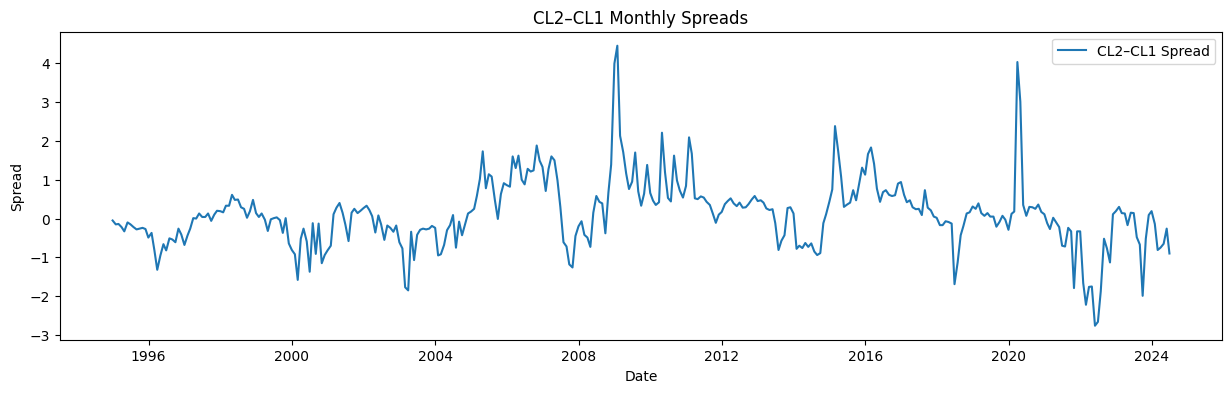

In [6]:
# Visulisaing spreads

plt.figure(figsize=(15, 4))
plt.plot(m["date"], y, label="CL2–CL1 Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Monthly Spreads")
plt.legend()
plt.show()

# Diagnostics and Explanatory Variable Selection

## Splitting the data into training and testing set

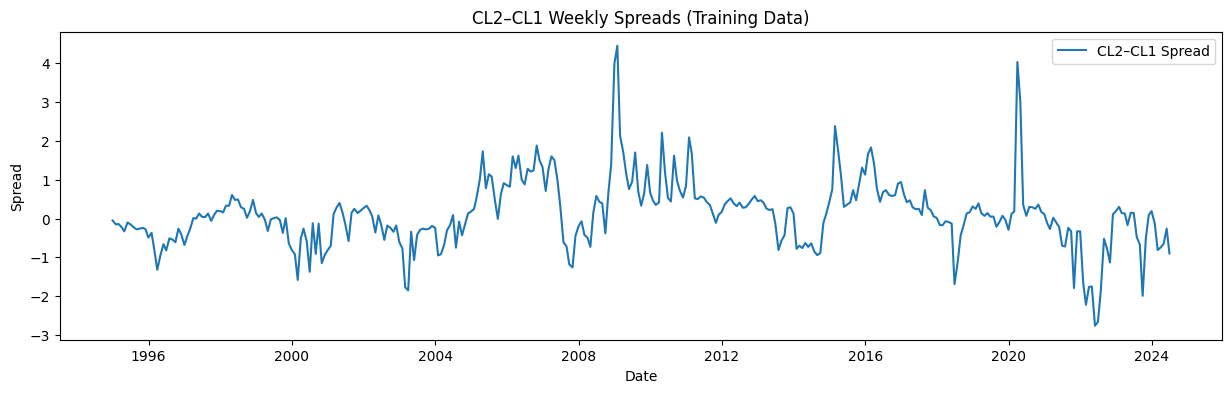

In [7]:
"""
Before we run any diagnostics and select any explanatory variables, we must start by splitting our data into a training 
and testing test. We should do this before running any diagonistics to prevent overfitting our data onto our testing 
sample and leading to unreliable out-of-sample results. 

We deice to utilise a 70:30 train:test split after observing the time-series plot above. The reason being that 
the training sample spans multiple market regimes, including periods of elevated volatility and structural stress, 
allowing the model to learn oil spread dynamics under diverse conditions. The test sample corresponds to a relatively 
stable regime, providing a rigourous evaluation of the model’s ability to generalise out of sample.
"""

# Create split slice
split = int(len(w) * 0.7)

# Creating training and testing sub-samples
m_train = m.iloc[:split]
m_test = m.iloc[split:]

# Plot training data to confirm split works
plt.figure(figsize=(15, 4))
plt.plot(m_train["date"], m_train["spread"], label="CL2–CL1 Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Weekly Spreads (Training Data)")
plt.legend()
plt.show()

## Diagnostic Tests

### Test for Stationarity 

Test for Stationarity:

ADF (Augmented-Dickey Fuller) Test
$$
H_0: \delta = 0 \text{ (Suggests non-stationarity)}\\
H_1: \delta < 0 \text{ (Suggests stationarity)}
$$

KPSS (Kwiatkowski–Phillips–Schmidt–Shin) Test
$$
H_0: \delta = 0 \text{ (Suggests stationarity)}\\
H_1: \delta < 0 \text{ (Suggests non-stationarity)}
$$

In [8]:
# Test for Stationarity (ADF and KPSS Test)

# ADF
adf_result = adfuller(m_train["spread"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")


# KPSS
kpss_stat, kpss_pvalue, lags, crit = kpss(
    m_train["spread"].dropna(),
    regression="c",   # "c" = level stationarity, "ct" = trend stationarity
    nlags="auto"
)

print("KPSS Statistic:", kpss_stat)
print("p-value:", kpss_pvalue)
print("Critical Values:")
for key, value in crit.items():
    print(f"  {key}: {value}")


ADF Statistic: -4.456937883939456
p-value: 0.00023503863546685632
Critical Values:
  1%: -3.44911857009962
  5%: -2.8698097654570507
  10%: -2.5711757061225153
KPSS Statistic: 0.31146976302194096
p-value: 0.1
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_10012/3208175908.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, lags, crit = kpss(


In [9]:
# Test for Stationarity (ADF and KPSS Test)

# Create a function for ADF and KPSS Test 
def stationarity_sum(series, name=""):
    series = series.dropna()

    adf = adfuller(series)
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")

    print(f"\n{name}")
    print("-" * len(name))
    print(f"ADF p-value  : {adf[1]:.4f}")
    print(f"KPSS p-value : {kpss_p:.4f}")


stationarity_sum(m_train["spread"], "CL2-CL1 Spread")


CL2-CL1 Spread
--------------
ADF p-value  : 0.0002
KPSS p-value : 0.1000


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_10012/3285853403.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")


The ADF test rejects the null of a unit root, while the KPSS test rejects the null of stationarity, suggesting that the series is mean-reverting but exhibits structural breaks or regime-dependent behaviour. <br>

We will difference the data and test for stationarity again for rigidness

In [10]:
# Difference the time-series
spread_d = m_train["spread"].diff().dropna()

stationarity_sum(spread_d, "CL2-CL1 Spread (Differenced)")


CL2-CL1 Spread (Differenced)
----------------------------
ADF p-value  : 0.0000
KPSS p-value : 0.1000


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_10012/3285853403.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")


Now both the ADF and KPSS test both suggest that there is enough statistical evidence at the 5% alpha, which suggests that when the time-series is differenced to the first degree (I=1), the time-series is stationary.<br>

Although first differencing yields statistically stationary behaviour, oil calendar spreads are theoretically mean-reverting. The spread is therefore modelled in levels as the primary specification, with differenced models estimated as robustness checks.<br>

However, moving forward, we will do perform out-of-sample forecasts using both models and see which model has higher predictive power [i.e. SARIMAX(p,0,q) and SARIMAX(p,1,q)].

### ACF and PACF Plot

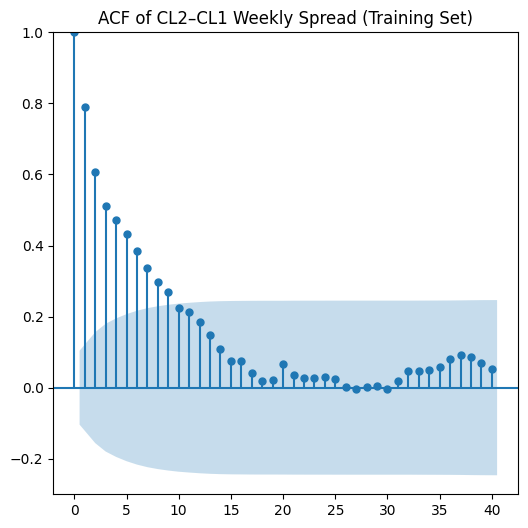

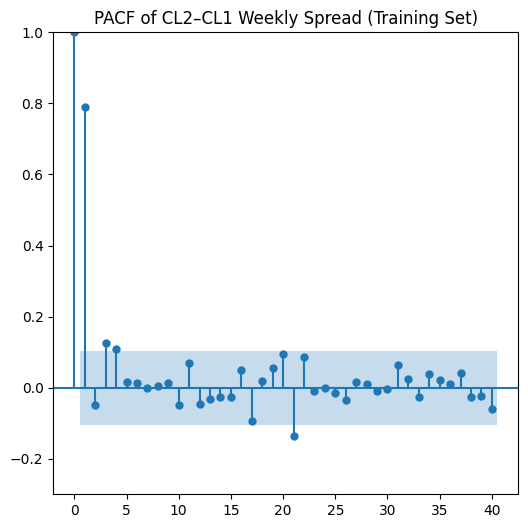

In [11]:
# ACF and PACF Plots

fig, ax = plt.subplots(figsize=(6, 6))
plot_acf(m_train["spread"], lags=40, ax=ax)
ax.set_title("ACF of CL2–CL1 Weekly Spread (Training Set)")
plt.ylim(-0.3,1)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
plot_pacf(m_train["spread"], lags=40, ax=ax)
ax.set_title("PACF of CL2–CL1 Weekly Spread (Training Set)")
plt.ylim(-0.3,1)
plt.show()


## Auto-ARIMA Optimal Lag Choice

In [12]:
import pmdarima as pm

# Define maximum lags
max_lags = 10

# Function to return model order AND IC values
def auto_arima_lag(series, max_lags, criterion):
    model = pm.auto_arima(
        series,
        start_p=0, start_q=0,
        max_p=max_lags, max_q=max_lags,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        information_criterion=criterion
    )
    
    return {
        "order": model.order,
        "AIC": model.aic(),
        "BIC": model.bic(),
        "HQIC": model.hqic()
    }

# Run for each criterion
results = {
    'AIC': auto_arima_lag(m_train['spread'], max_lags, 'aic'),
    'BIC': auto_arima_lag(m_train['spread'], max_lags, 'bic'),
    'HQIC': auto_arima_lag(m_train['spread'], max_lags, 'hqic')
}

# Print results cleanly
for criterion, output in results.items():
    print(f"\nOptimised by {criterion}")
    print(f"Selected order: {output['order']}")
    print(f"AIC: {output['AIC']:.4f}")
    print(f"BIC: {output['BIC']:.4f}")
    print(f"HQIC: {output['HQIC']:.4f}")



Optimised by AIC
Selected order: (4, 1, 1)
AIC: 559.8052
BIC: 583.0210
HQIC: 569.0421

Optimised by BIC
Selected order: (1, 1, 1)
AIC: 563.6751
BIC: 575.2830
HQIC: 568.2935

Optimised by HQIC
Selected order: (1, 1, 1)
AIC: 563.6751
BIC: 575.2830
HQIC: 568.2935


## Fitting ARIMA(4,1,1)

In [13]:
# Using optimal lags from AIC

model_arima = ARIMA(y, order=(4, 0, 1))   
results_arima = model_arima.fit()

print(results_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 spread   No. Observations:                  355
Model:                 ARIMA(4, 0, 1)   Log Likelihood                -273.069
Date:                Wed, 11 Feb 2026   AIC                            560.138
Time:                        02:54:37   BIC                            587.243
Sample:                             0   HQIC                           570.921
                                - 355                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0862      0.194      0.444      0.657      -0.294       0.467
ar.L1          1.0220      0.495      2.066      0.039       0.052       1.992
ar.L2         -0.3092      0.408     -0.758      0.4

### Evaluating ARIMA (4,1,1)

Residual Diagnostic Expectations (ARIMA / ARIMAX)

| Test | Null Hypothesis (H₀) | What We Want | Interpretation if Significant |
|------|----------------------|--------------|-------------------------------|
| **Residual ACF** | No significant autocorrelation at any lag | No spikes outside confidence bands | Additional AR or MA terms may be required |
| **Ljung–Box** | No autocorrelation in residuals | **p > 0.05** | Remaining serial correlation → ARIMA structure may be misspecified |
| **ARCH Test** | No conditional heteroskedasticity | **p > 0.05** (ideal) | Volatility clustering present (common in financial/commodity data) |
| **Jarque–Bera** | Residuals are normally distributed | p > 0.05 (nice but not required) | Heavy tails / non-normality (very common in oil markets) |

<Axes: title={'center': 'ARIMA Residuals'}>

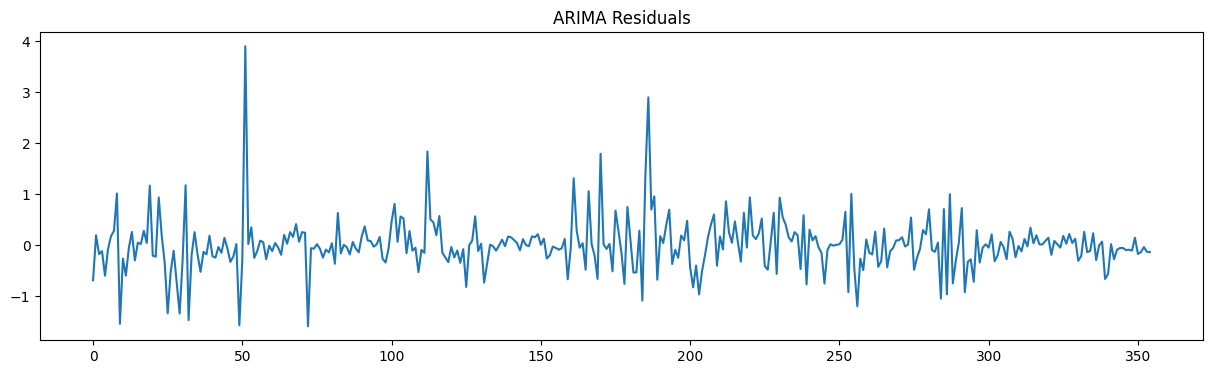

In [14]:
# Residuals plot
residuals_arima = results_arima.resid
residuals_arima.plot(figsize=(15,4), title="ARIMA Residuals")

In [15]:
# Ljung-Box test (we are looking for statistical insignifiance as we want white noise)

ljung_box = acorr_ljungbox(residuals_arima, lags=[10], return_df=True)
print("Ljung box test p-value:", ljung_box["lb_pvalue"].iloc[0])

Ljung box test p-value: 0.9975084617781703


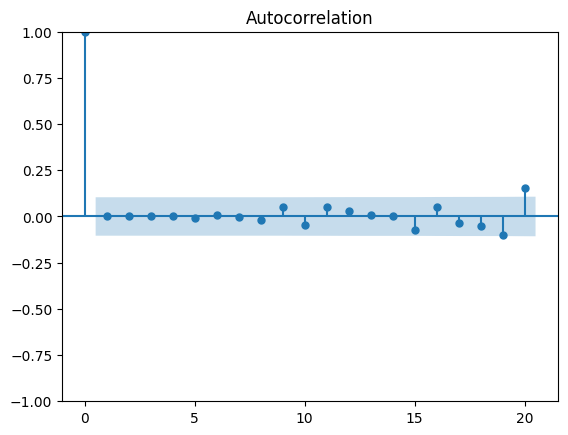

In [16]:
# Residual ACF
plot_acf(residuals_arima, lags=20);

In [17]:
arch_test = het_arch(residuals_arima)
print("ARCH test p-value:", arch_test[1])

ARCH test p-value: 0.7358041058217109


In [25]:
jb_stat, jb_pvalue, skew, kurt = jarque_bera(residuals_arima)

print("Jarque-Bera p-value:", jb_pvalue)

Jarque-Bera p-value: 0.0


We believe we can do better by forming an ARIMAX(p,d,q)..... finish off here and do explanatory variable diagnostics

# ARIMAX Model

## Selecting Explanatory/Exogenous Variables

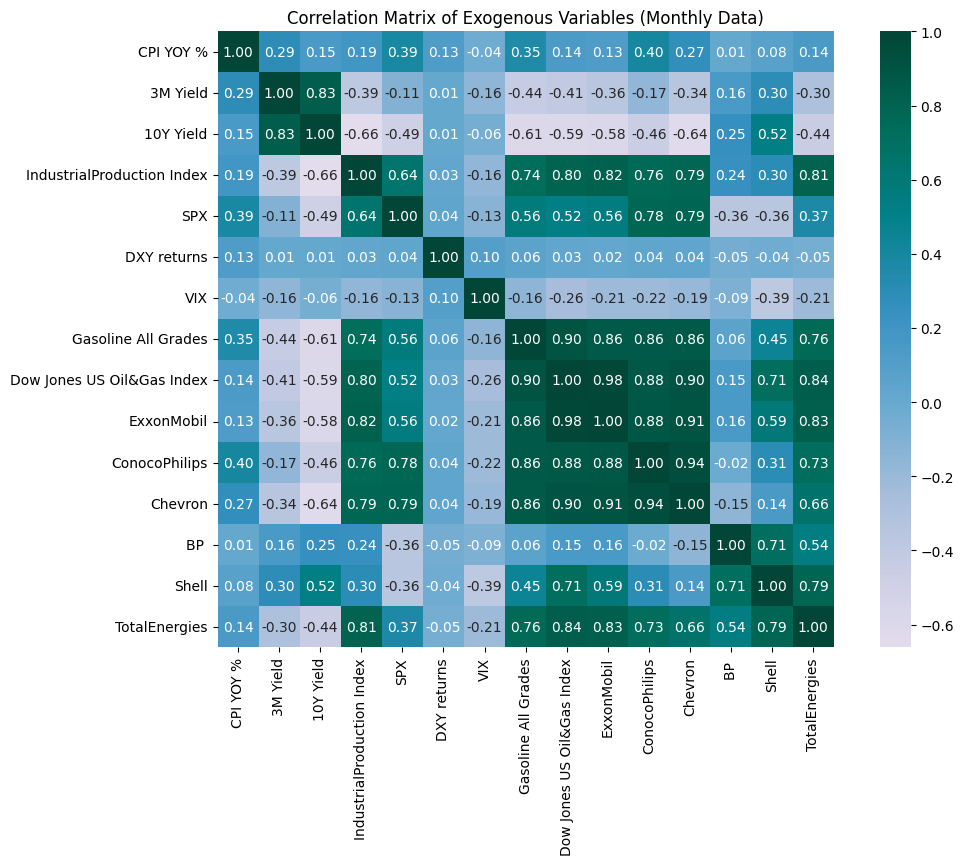

In [19]:
"""
Gauss-Markov Theorem:
1. E[u_t] = 0, Errors have a mean of 0
2. Var(u_t) = 0, Errors are homoskedastic, i.e. errors have a constant variance
3. Cov (u_t, v_t) = 0, Errors are uncorrelated to one another
4. Cov(u_t, x_t) = 0, Error term and explanatory variables should be uncorrelated to each other
5. Error term should follow a Guassian Distribution

The following tests that we run will keep the following in mind and test for diagnostics, such as 
multicollinearity and standard error robustness to ensure that our model is as accurate as possible, whilst maintaining a relative alignment
to the G-M assumptions
"""

for exog in [macro, prices]:
    exog.index = pd.to_datetime(exog.index)
    exog.sort_index(inplace=True)

exog = pd.concat(
    [
        macro.drop(columns=["Date"]),
        prices.drop(columns=["Date"])
    ],
    axis=1
)


# Correlation Matrix (for exogenous variables)
exog_corr = exog.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(
    exog_corr,
    annot=True,
    fmt=".2f",
    cmap="PuBuGn",
    center=0,
    square=True
)
plt.title("Correlation Matrix of Exogenous Variables (Monthly Data)")
plt.show()


# Conducting out-of-sample forecasts

In [20]:
"""
Before conducing out-of-sample forecasts, since our objective of forecasting oil market dynamics, a standard machine-learning approach based on a single static train–test 
split is inappropriate. Instead, forecasts are generated using a rolling-window framework, which more closely reflects real-world 
oil trading conditions. Oil markets are highly non-stationary and are influenced by evolving supply–demand dynamics, seasonal 
effects, and geopolitical events. Rolling estimation allows model parameters to adapt over time and prevents historical regimes 
from unduly influencing current forecasts.

This approach results in a sequence of strictly out-of-sample predictions and provides a more reliable assessment of 
forecast performance in a realistic trading environment.

We decide to create 3-month windows for our forecasting predictions [so our first window would be between (t,t+2) 
and our second window would be (t+1,t+3), ... (t+n,t+n+2)].

We also deicde to rolling estimation winodws of length three months. At each forecast origin, t, the model is estimated using observations 
from (t-2, t) and used to generate a one-step-ahead forecast. The window is then rolled forward by one period, resulting in 
successive estimation widnows (t-1,t+1), (t,t+2) and etc.
"""

def train_test(
        df,
        feature_cols,
        target_col,
        train_window=36,
        horizon=1,
        step=1,
        split_ratio=0.7,
        dropna=True
):
    """
    Rolling train/test generator that:
    - Uses full dataset for estimation
    - Only yields forecasts inside the test period (last 30% by default)
    """

    # Copy dataset
    data = df.copy()

    if dropna:
        data = data.dropna(subset=feature_cols + [target_col])

    n = len(data)

    # Define 70:30 split index
    split_idx = int(split_ratio * n)

    # Last possible training index
    last_start = n - horizon

    for end_train in range(train_window, last_start, step):

        # Only start producing forecasts once test region begins
        forecast_index = end_train + horizon - 1
        if forecast_index < split_idx:
            continue

        train = data.iloc[end_train - train_window:end_train]
        test = data.iloc[forecast_index: forecast_index + 1]

        X_train = train[feature_cols]
        y_train = train[target_col]

        X_test = test[feature_cols]
        y_test = test[target_col]

        yield X_train, y_train, X_test, y_test